In [19]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from scipy.stats import t

In [21]:
df = pd.read_csv("btcusd_1-min_data.csv")

# Convert timestamp to datetime and set index
df["date"] = pd.to_datetime(df["Timestamp"], unit="s")
df = df.set_index("date").sort_index()

# Keep only the close price for daily risk modeling
btc_daily = df["Close"].resample("1D").last().dropna().to_frame()

# Daily percentage returns
btc_daily["return_pct"] = btc_daily["Close"].pct_change() * 100
btc_daily = btc_daily.dropna()

data = btc_daily.copy()

print("Data shape:", data.shape)
print("Start:", data.index.min())
print("End:", data.index.max())

Data shape: (5185, 2)
Start: 2012-01-02 00:00:00
End: 2026-03-13 00:00:00


In [23]:
# Train/Test split

split = int(len(data) * 0.8)

train = data.iloc[:split].copy()
test = data.iloc[split:].copy()

print("\nTrain period:", train.index.min(), "to", train.index.max())
print("Test period :", test.index.min(), "to", test.index.max())


Train period: 2012-01-02 00:00:00 to 2023-05-11 00:00:00
Test period : 2023-05-12 00:00:00 to 2026-03-13 00:00:00


In [25]:
# Helper functions

def student_t_expected_shortfall(alpha: float, nu: float) -> float:
    """
    Left-tail Expected Shortfall for a standardized Student-t random variable
    scaled to unit variance.

    Returns ES_alpha such that ES < VaR for left-tail losses.
    """
    if nu <= 2:
        raise ValueError("nu must be > 2 for finite variance.")

    # Quantile of ordinary Student-t with df=nu
    z_alpha = t.ppf(alpha, df=nu)

    # PDF at quantile
    pdf_z = t.pdf(z_alpha, df=nu)

    # ES for ordinary t
    es_raw = -((nu + z_alpha**2) / ((nu - 1) * alpha)) * pdf_z

    # Scale to unit variance because arch_model uses standardized t
    scale = np.sqrt((nu - 2) / nu)

    return es_raw * scale


def fit_garch_t(series: pd.Series):
    """
    Fit GARCH(1,1) with Student-t innovations.
    """
    model = arch_model(
        series,
        mean="constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="t"
    )
    result = model.fit(disp="off")
    return result


def rolling_garch_var_es_forecast(series: pd.Series, split_idx: int, alpha_levels=(0.05, 0.01)):
    """
    Rolling 1-step-ahead forecasts for:
    - mean
    - variance
    - volatility
    - parametric VaR
    - parametric ES
    using GARCH(1,1) with Student-t innovations
    """
    records = []

    for i in range(split_idx, len(series)):
        train_slice = series.iloc[:i]

        res = fit_garch_t(train_slice)

        forecast = res.forecast(horizon=1, reindex=False)

        mu_f = forecast.mean.values[-1, 0]
        var_f = forecast.variance.values[-1, 0]
        vol_f = np.sqrt(var_f)

        nu = res.params["nu"]

        row = {
            "date": series.index[i],
            "mean_forecast": mu_f,
            "variance_forecast": var_f,
            "vol_forecast": vol_f,
            "nu": nu,
        }

        for alpha in alpha_levels:
            q_alpha = res.model.distribution.ppf(alpha, [nu])
            es_alpha = student_t_expected_shortfall(alpha, nu)

            row[f"VaR_{int(alpha*100)}_parametric"] = mu_f + vol_f * q_alpha
            row[f"ES_{int(alpha*100)}_parametric"] = mu_f + vol_f * es_alpha

        records.append(row)

    out = pd.DataFrame(records).set_index("date")
    return out


def empirical_var_es(std_resid: pd.Series, alpha: float):
    """
    Empirical left-tail VaR and ES from standardized residuals.
    """
    q = std_resid.quantile(alpha)
    es = std_resid[std_resid <= q].mean()
    return q, es

In [27]:
# Base Model on Train Set

base_res = fit_garch_t(train["return_pct"])
print(base_res.summary())

# Empirical quantiles from train standardized residuals
std_resid_train = pd.Series(base_res.std_resid).dropna()

q5_emp, es5_emp = empirical_var_es(std_resid_train, 0.05)
q1_emp, es1_emp = empirical_var_es(std_resid_train, 0.01)

print("\nEmpirical standardized residual metrics")
print("5% empirical quantile :", q5_emp)
print("5% empirical ES       :", es5_emp)
print("1% empirical quantile :", q1_emp)
print("1% empirical ES       :", es1_emp)

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   return_pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -10760.6
Distribution:      Standardized Student's t   AIC:                           21531.2
Method:                  Maximum Likelihood   BIC:                           21562.9
                                              No. Observations:                 4148
Date:                      Sat, Mar 14 2026   Df Residuals:                     4147
Time:                              22:29:35   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0

In [29]:
# Rolling Parametric VaR + ES Forecast

forecast_df = rolling_garch_var_es_forecast(
    data["return_pct"],
    split_idx=split,
    alpha_levels=(0.05, 0.01)
)

forecast_df["actual_return"] = test["return_pct"].reindex(forecast_df.index)

# Empirical VaR / ES using rolling GARCH volatility forecast
forecast_df["VaR_5_empirical"] = (
    forecast_df["mean_forecast"] + forecast_df["vol_forecast"] * q5_emp
)
forecast_df["ES_5_empirical"] = (
    forecast_df["mean_forecast"] + forecast_df["vol_forecast"] * es5_emp
)

forecast_df["VaR_1_empirical"] = (
    forecast_df["mean_forecast"] + forecast_df["vol_forecast"] * q1_emp
)
forecast_df["ES_1_empirical"] = (
    forecast_df["mean_forecast"] + forecast_df["vol_forecast"] * es1_emp
)

forecast_df = forecast_df.dropna()

print("\nForecast table head:")
print(forecast_df.head())


Forecast table head:
            mean_forecast  variance_forecast  vol_forecast        nu  \
date                                                                   
2023-05-12       0.171455           9.586591      3.096222  3.405756   
2023-05-13       0.170902           8.800591      2.966579  3.405740   
2023-05-14       0.171292           7.998863      2.828226  3.405314   
2023-05-15       0.171158           7.077779      2.660410  3.403921   
2023-05-16       0.171860           6.759373      2.599879  3.404542   

            VaR_5_parametric  ES_5_parametric  VaR_1_parametric  \
date                                                              
2023-05-12         -4.291027        -6.845280         -8.054493   
2023-05-13         -4.104723        -6.552032         -7.710613   
2023-05-14         -3.904744        -6.238072         -7.342620   
2023-05-15         -3.662453        -5.857801         -6.896811   
2023-05-16         -3.574776        -5.719969         -6.735339   

   

In [31]:
# Backtest VaR Exceedences

forecast_df["exceed_5_parametric"] = (
    forecast_df["actual_return"] < forecast_df["VaR_5_parametric"]
)
forecast_df["exceed_5_empirical"] = (
    forecast_df["actual_return"] < forecast_df["VaR_5_empirical"]
)

forecast_df["exceed_1_parametric"] = (
    forecast_df["actual_return"] < forecast_df["VaR_1_parametric"]
)
forecast_df["exceed_1_empirical"] = (
    forecast_df["actual_return"] < forecast_df["VaR_1_empirical"]
)

backtest_var = pd.DataFrame({
    "Model": [
        "5% Parametric VaR",
        "5% Empirical VaR",
        "1% Parametric VaR",
        "1% Empirical VaR"
    ],
    "Expected Rate": [0.05, 0.05, 0.01, 0.01],
    "Observed Rate": [
        forecast_df["exceed_5_parametric"].mean(),
        forecast_df["exceed_5_empirical"].mean(),
        forecast_df["exceed_1_parametric"].mean(),
        forecast_df["exceed_1_empirical"].mean()
    ],
    "Exceedance Count": [
        forecast_df["exceed_5_parametric"].sum(),
        forecast_df["exceed_5_empirical"].sum(),
        forecast_df["exceed_1_parametric"].sum(),
        forecast_df["exceed_1_empirical"].sum()
    ]
})

backtest_var["Difference"] = backtest_var["Observed Rate"] - backtest_var["Expected Rate"]

print("\nVaR backtest summary")
print(backtest_var)


VaR backtest summary
               Model  Expected Rate  Observed Rate  Exceedance Count  \
0  5% Parametric VaR           0.05       0.054002                56   
1   5% Empirical VaR           0.05       0.042430                44   
2  1% Parametric VaR           0.01       0.008679                 9   
3   1% Empirical VaR           0.01       0.005786                 6   

   Difference  
0    0.004002  
1   -0.007570  
2   -0.001321  
3   -0.004214  


In [55]:
# ES Evaluation

def evaluate_es(actual_returns: pd.Series, var_series: pd.Series, es_series: pd.Series, label: str):
    """
    Evaluate ES using tail losses only:
    - tail event count
    - average realized loss conditional on VaR exceedance
    - average forecast ES conditional on VaR exceedance
    """
    mask = actual_returns < var_series
    tail_realized = actual_returns[mask]
    tail_es = es_series[mask]

    if len(tail_realized) == 0:
        return {
            "Model": label,
            "Tail Event Count": 0,
            "Avg Realized Tail Loss": np.nan,
            "Avg Forecast ES": np.nan,
            "Gap (Realized - ES)": np.nan
        }

    avg_realized = tail_realized.mean()
    avg_es = tail_es.mean()

    return {
        "Model": label,
        "Tail Event Count": int(mask.sum()),
        "Avg Realized Tail Loss": avg_realized,
        "Avg Forecast ES": avg_es,
        "Gap (Realized - ES)": avg_realized - avg_es
    }

es_eval = pd.DataFrame([
    evaluate_es(
        forecast_df["actual_return"],
        forecast_df["VaR_5_parametric"],
        forecast_df["ES_5_parametric"],
        "5% Parametric ES"
    ),
    evaluate_es(
        forecast_df["actual_return"],
        forecast_df["VaR_5_empirical"],
        forecast_df["ES_5_empirical"],
        "5% Empirical ES"
    ),
    evaluate_es(
        forecast_df["actual_return"],
        forecast_df["VaR_1_parametric"],
        forecast_df["ES_1_parametric"],
        "1% Parametric ES"
    ),
    evaluate_es(
        forecast_df["actual_return"],
        forecast_df["VaR_1_empirical"],
        forecast_df["ES_1_empirical"],
        "1% Empirical ES"
    ),
])

print("\nES evaluation summary")
print(es_eval)


ES evaluation summary
              Model  Tail Event Count  Avg Realized Tail Loss  \
0  5% Parametric ES                56               -4.951347   
1   5% Empirical ES                44               -5.339004   
2  1% Parametric ES                 9               -7.517447   
3   1% Empirical ES                 6               -8.458523   

   Avg Forecast ES  Gap (Realized - ES)  
0        -5.349329             0.397982  
1        -5.746066             0.407062  
2        -9.009822             1.492375  
3        -9.543150             1.084627  


In [57]:
# Risk Summary Table

risk_summary = pd.DataFrame({
    "Metric": [
        "Avg 5% Parametric VaR",
        "Avg 5% Parametric ES",
        "Avg 5% Empirical VaR",
        "Avg 5% Empirical ES",
        "Avg 1% Parametric VaR",
        "Avg 1% Parametric ES",
        "Avg 1% Empirical VaR",
        "Avg 1% Empirical ES"
    ],
    "Value": [
        forecast_df["VaR_5_parametric"].mean(),
        forecast_df["ES_5_parametric"].mean(),
        forecast_df["VaR_5_empirical"].mean(),
        forecast_df["ES_5_empirical"].mean(),
        forecast_df["VaR_1_parametric"].mean(),
        forecast_df["ES_1_parametric"].mean(),
        forecast_df["VaR_1_empirical"].mean(),
        forecast_df["ES_1_empirical"].mean(),
    ]
})

print("\nRisk summary")
print(risk_summary)


Risk summary
                  Metric      Value
0  Avg 5% Parametric VaR  -3.707273
1   Avg 5% Parametric ES  -5.960001
2   Avg 5% Empirical VaR  -4.107142
3    Avg 5% Empirical ES  -6.397513
4  Avg 1% Parametric VaR  -7.015002
5   Avg 1% Parametric ES -10.433456
6   Avg 1% Empirical VaR  -7.629248
7    Avg 1% Empirical ES -10.521773


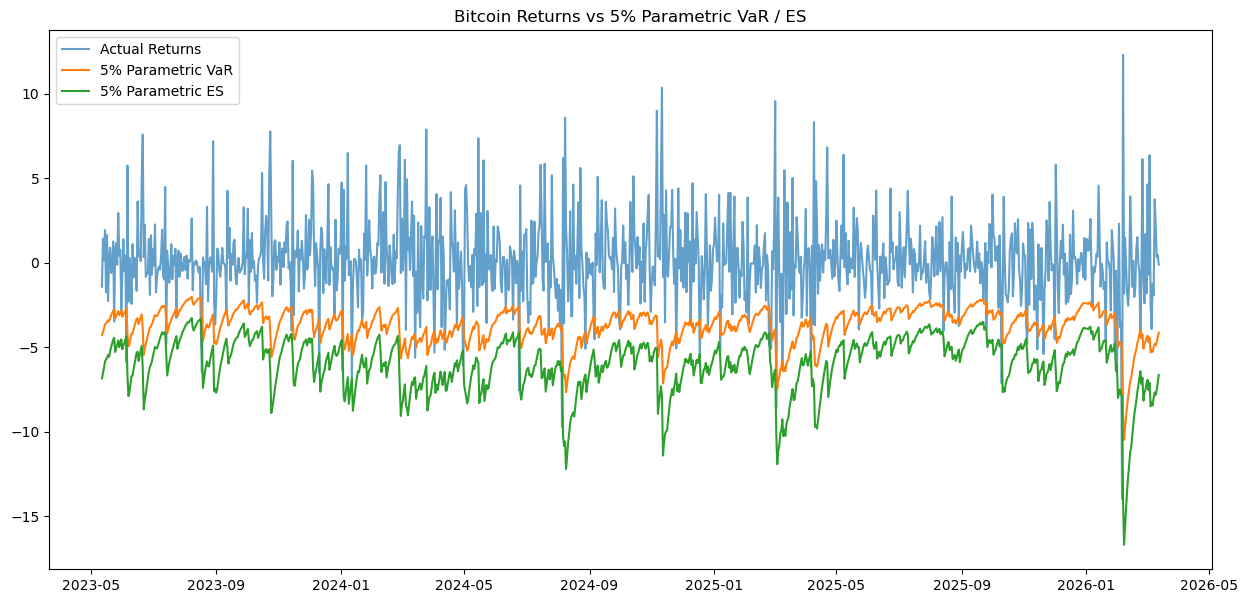

In [59]:
# Visualizations

# ---- 9A) 5% Parametric VaR + ES
plt.figure(figsize=(15, 7))
plt.plot(forecast_df.index, forecast_df["actual_return"], label="Actual Returns", alpha=0.7)
plt.plot(forecast_df.index, forecast_df["VaR_5_parametric"], label="5% Parametric VaR")
plt.plot(forecast_df.index, forecast_df["ES_5_parametric"], label="5% Parametric ES")
plt.title("Bitcoin Returns vs 5% Parametric VaR / ES")
plt.legend()
plt.show()

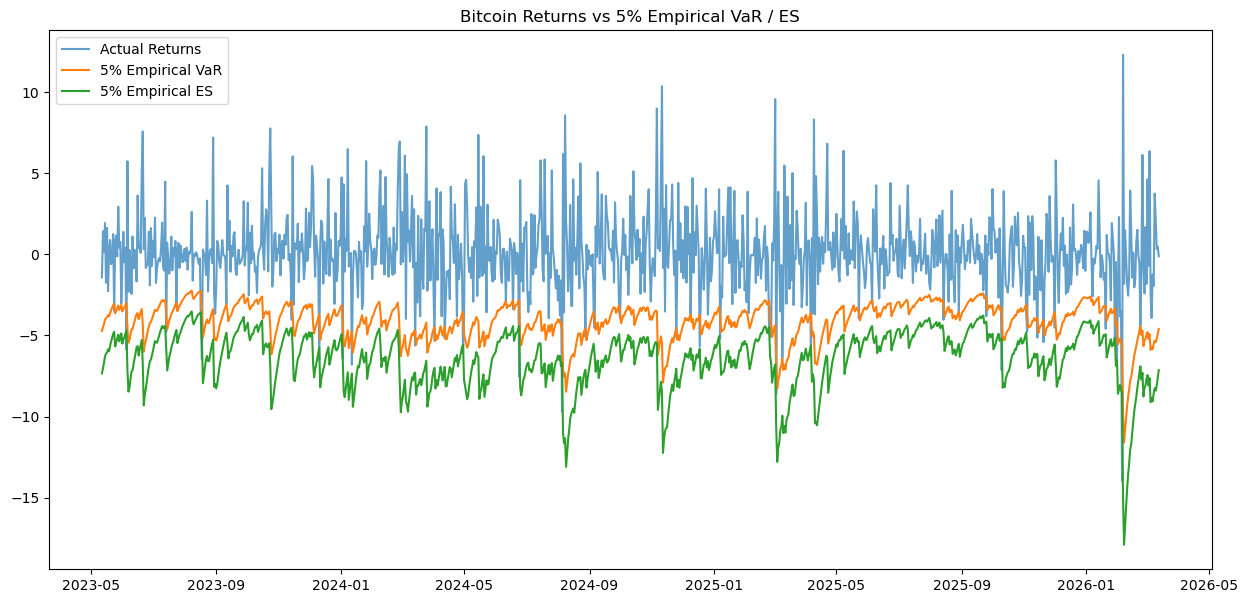

In [61]:
# ---- 9B) 5% Empirical VaR + ES
plt.figure(figsize=(15, 7))
plt.plot(forecast_df.index, forecast_df["actual_return"], label="Actual Returns", alpha=0.7)
plt.plot(forecast_df.index, forecast_df["VaR_5_empirical"], label="5% Empirical VaR")
plt.plot(forecast_df.index, forecast_df["ES_5_empirical"], label="5% Empirical ES")
plt.title("Bitcoin Returns vs 5% Empirical VaR / ES")
plt.legend()
plt.show()

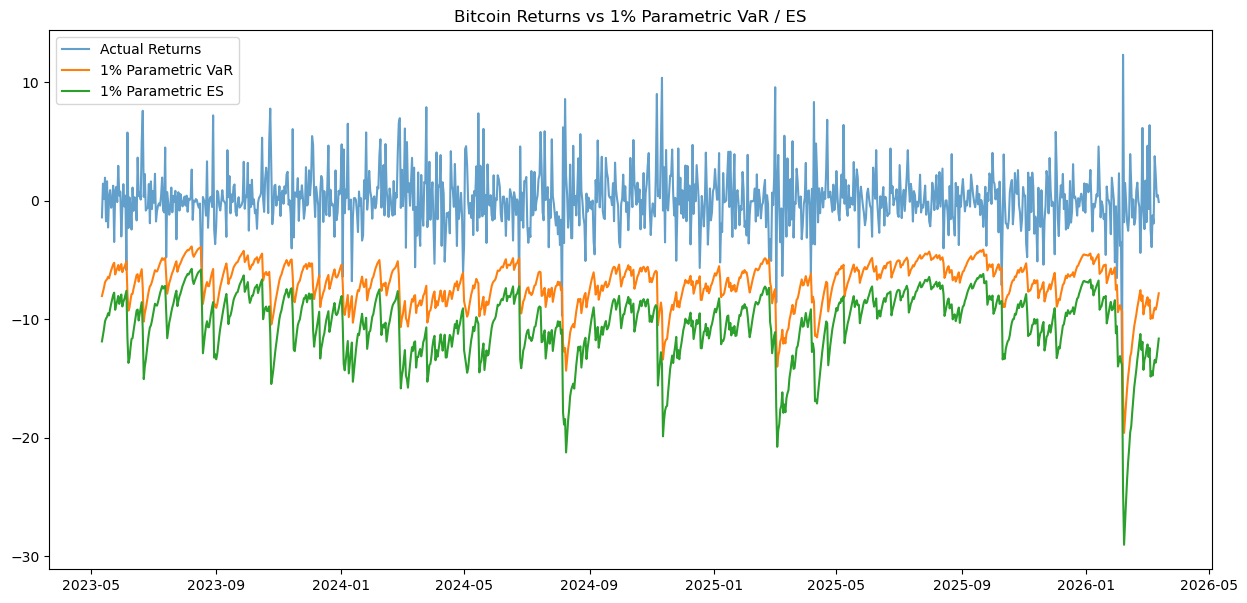

In [62]:
# ---- 9C) 1% Parametric VaR + ES
plt.figure(figsize=(15, 7))
plt.plot(forecast_df.index, forecast_df["actual_return"], label="Actual Returns", alpha=0.7)
plt.plot(forecast_df.index, forecast_df["VaR_1_parametric"], label="1% Parametric VaR")
plt.plot(forecast_df.index, forecast_df["ES_1_parametric"], label="1% Parametric ES")
plt.title("Bitcoin Returns vs 1% Parametric VaR / ES")
plt.legend()
plt.show()

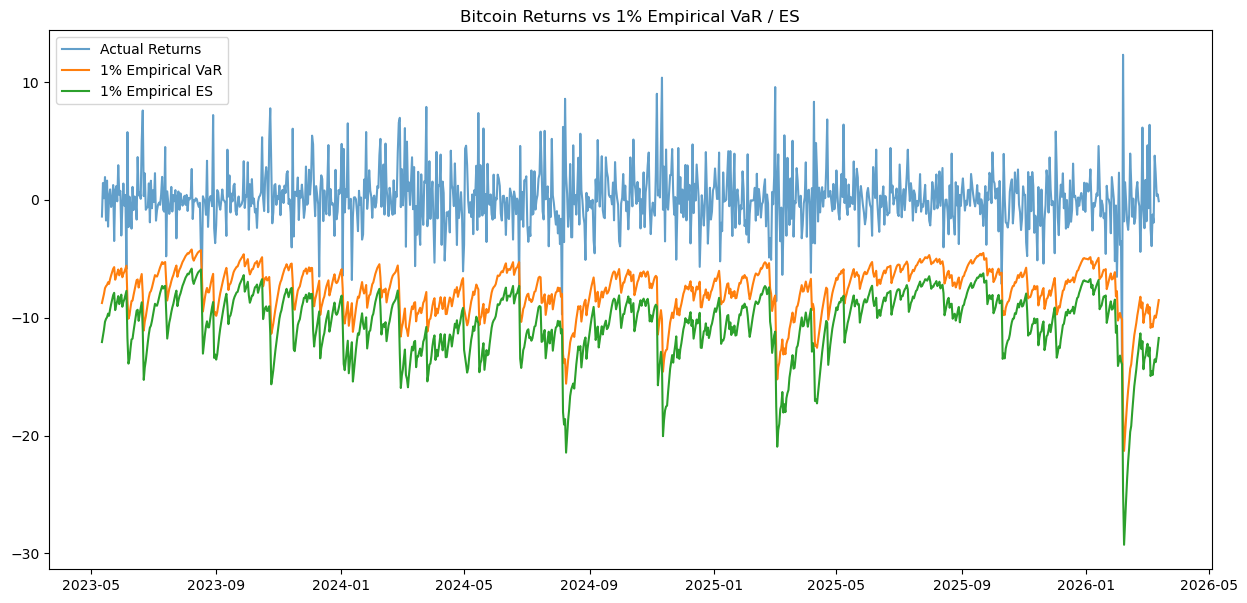

In [65]:
# ---- 9D) 1% Empirical VaR + ES
plt.figure(figsize=(15, 7))
plt.plot(forecast_df.index, forecast_df["actual_return"], label="Actual Returns", alpha=0.7)
plt.plot(forecast_df.index, forecast_df["VaR_1_empirical"], label="1% Empirical VaR")
plt.plot(forecast_df.index, forecast_df["ES_1_empirical"], label="1% Empirical ES")
plt.title("Bitcoin Returns vs 1% Empirical VaR / ES")
plt.legend()
plt.show()

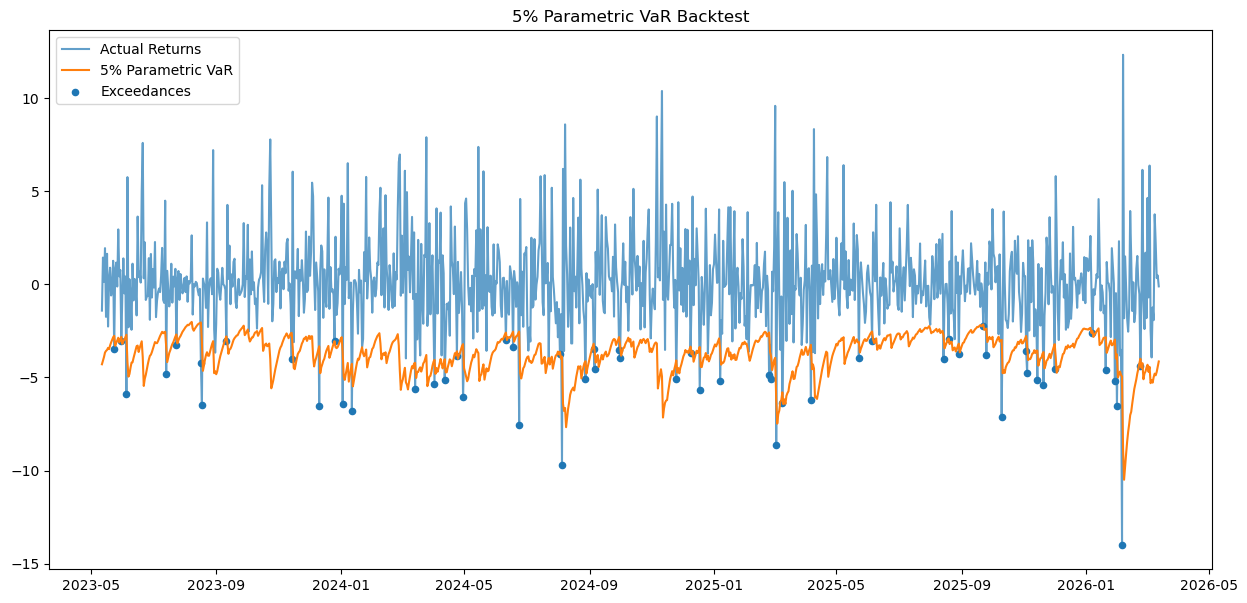

In [67]:
# ---- 9E) Exceedances against 5% Parametric VaR
plt.figure(figsize=(15, 7))
plt.plot(forecast_df.index, forecast_df["actual_return"], label="Actual Returns", alpha=0.7)
plt.plot(forecast_df.index, forecast_df["VaR_5_parametric"], label="5% Parametric VaR")

mask = forecast_df["exceed_5_parametric"]
plt.scatter(
    forecast_df.index[mask],
    forecast_df.loc[mask, "actual_return"],
    label="Exceedances",
    s=20
)

plt.title("5% Parametric VaR Backtest")
plt.legend()
plt.show()

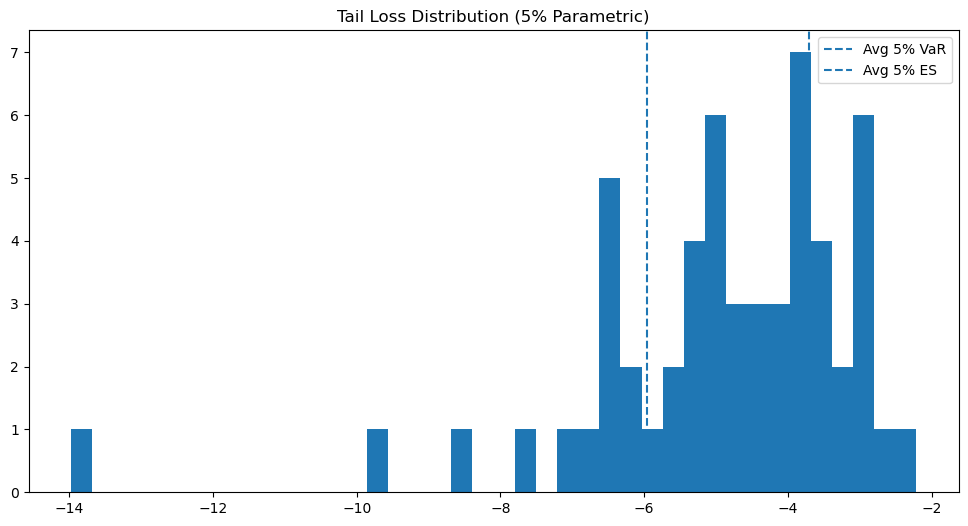

In [69]:
# ---- 9F) Tail loss histogram: 5% Parametric
tail_losses_5p = forecast_df.loc[
    forecast_df["actual_return"] < forecast_df["VaR_5_parametric"],
    "actual_return"
]

plt.figure(figsize=(12, 6))
plt.hist(tail_losses_5p, bins=40)
plt.axvline(forecast_df["VaR_5_parametric"].mean(), linestyle="--", label="Avg 5% VaR")
plt.axvline(forecast_df["ES_5_parametric"].mean(), linestyle="--", label="Avg 5% ES")
plt.title("Tail Loss Distribution (5% Parametric)")
plt.legend()
plt.show()

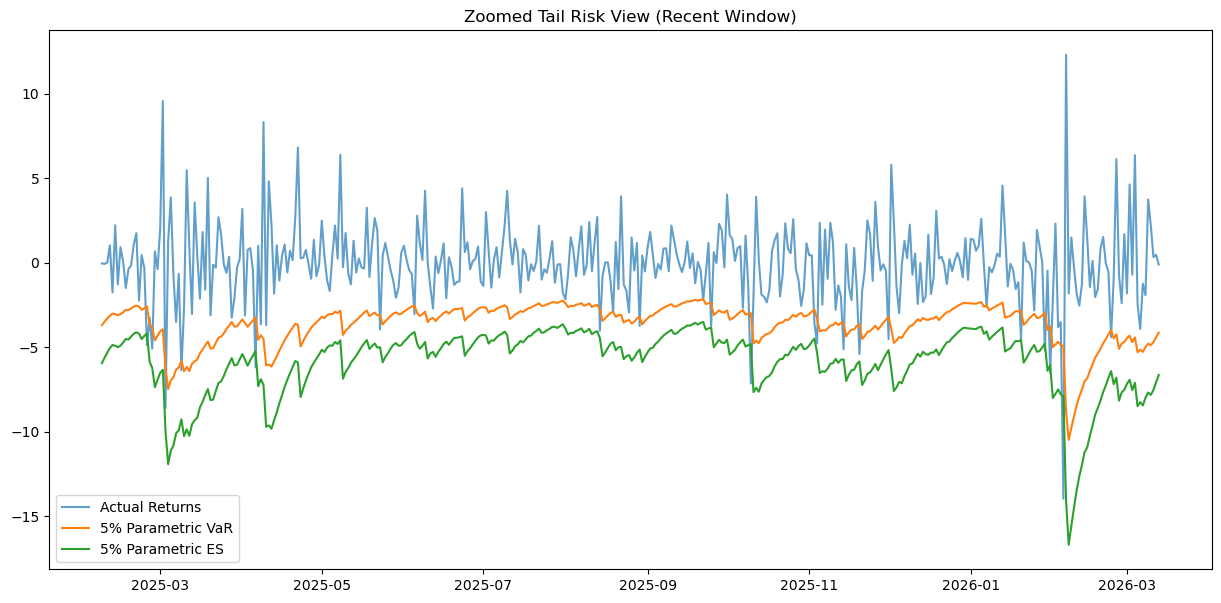

In [71]:
# ---- 9G) Zoomed recent window for readability
subset = forecast_df.tail(400)

plt.figure(figsize=(15, 7))
plt.plot(subset.index, subset["actual_return"], label="Actual Returns", alpha=0.7)
plt.plot(subset.index, subset["VaR_5_parametric"], label="5% Parametric VaR")
plt.plot(subset.index, subset["ES_5_parametric"], label="5% Parametric ES")
plt.title("Zoomed Tail Risk View (Recent Window)")
plt.legend()
plt.show()